# 📊 Análise de Experiência do Booster e Confiabilidade da SpaceX
**Autor:** Izac (Analista de Experiência e Confiabilidade)

## 🔍 Foco da Pesquisa
Existe correlação entre a experiência prévia de um booster (número de voos anteriores, ou `reuse_count`) e a sua taxa de sucesso na missão atual? Esta análise busca responder se foguetes mais "veteranos" são mais confiáveis ou se sofrem desgaste, controlando pelo "Efeito Teto" (ceiling effect) e agrupando os níveis de experiência.

## 1. Setup
Configuração do ambiente, imports de bibliotecas estatísticas, definição da paleta de cores padrão do projeto e carregamento do dataset oficial.

In [7]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\izacr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# Definindo estilo de plotagem premium (Padrão da Equipe)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

# Cores do projeto
colors = {
    'primary': '#0f4c81',      # Azul escuro
    'accent': '#d9534f',       # Coral
    'success': '#2ecc71',      # Verde suave
    'dark_grey': '#2c3e50'
}

# Carga do Dataset (Fonte única da verdade)
df = pd.read_csv('../../data/processed/processed_dataset_v1.csv') 

# Criamos uma versão puramente numérica (0 e 1) da coluna de sucesso para os testes
df['success_num'] = df['success'].astype(int)

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]} (esperado: 192)")
print(f"Colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Linhas: 192 (esperado: 192)
Colunas: 10


## 2. Exploração Inicial (Distribuição de Experiência)
Vamos verificar como a experiência dos boosters se distribui no nosso conjunto de dados (Q1).

=== RESUMO ESTATÍSTICO DE REUSOS ===
count    192.00
mean       5.12
std        4.73
min        0.00
25%        1.00
50%        4.00
75%        9.00
max       13.00
Name: reuse_count, dtype: float64

=== CONTAGEM DE FOGUETES POR NÚMERO DE VOOS ===
reuse_count
0     43
1     32
2      6
3     12
4      5
5     12
6     13
8      9
9     20
12    26
13    14
Name: count, dtype: int64


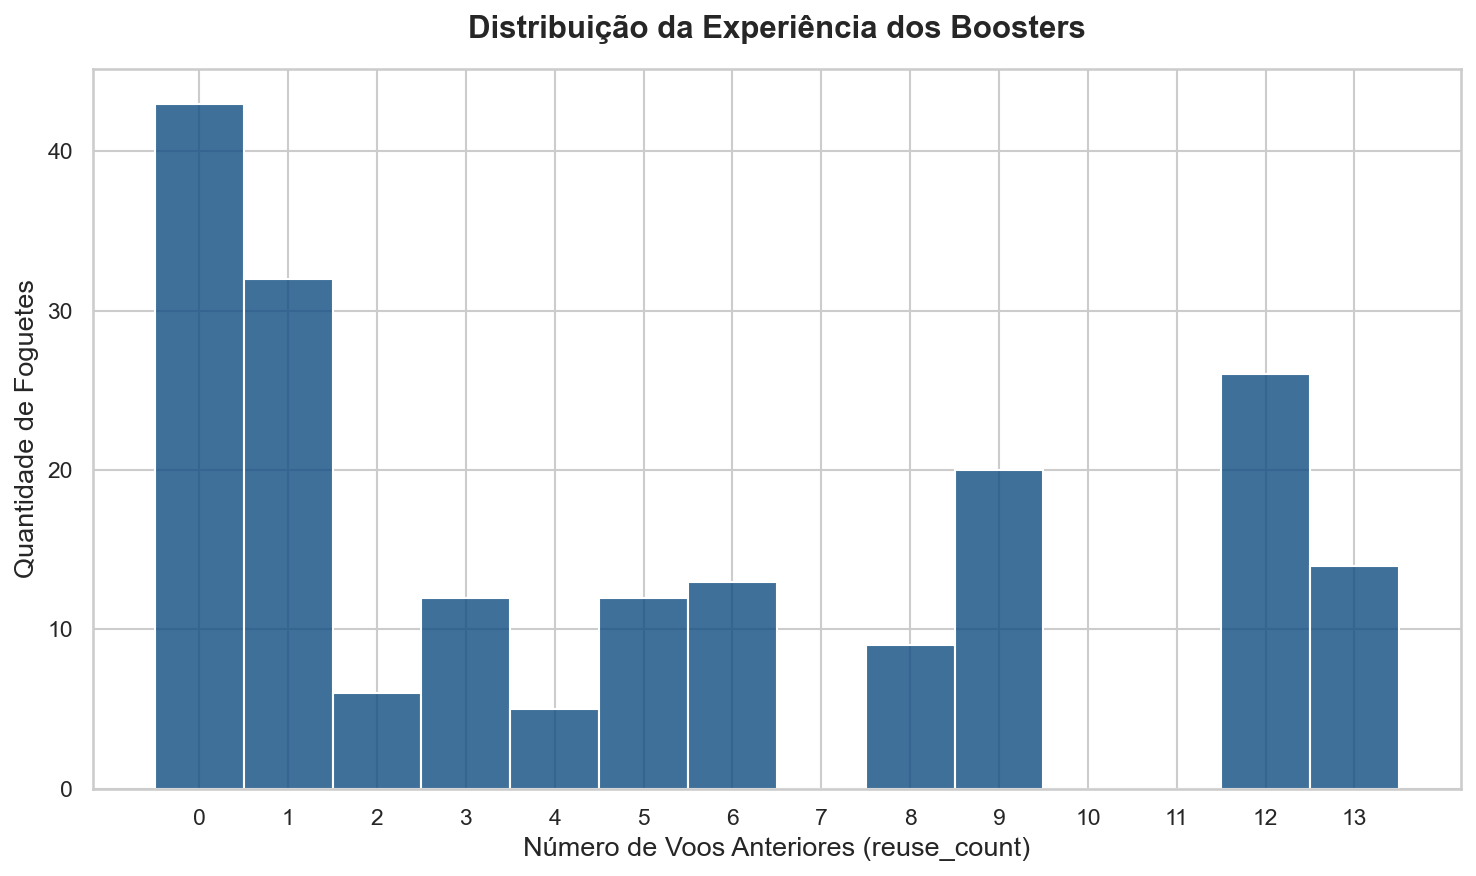

In [9]:
print("=== RESUMO ESTATÍSTICO DE REUSOS ===")
print(df['reuse_count'].describe().round(2))

print("\n=== CONTAGEM DE FOGUETES POR NÚMERO DE VOOS ===")
print(df['reuse_count'].value_counts().sort_index())

# Gráfico 1: Distribuição (Histograma)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='reuse_count', discrete=True, color=colors['primary'], alpha=0.8)

plt.title('Distribuição da Experiência dos Boosters', pad=15, fontweight='bold')
plt.xlabel('Número de Voos Anteriores (reuse_count)')
plt.ylabel('Quantidade de Foguetes')
plt.xticks(range(0, 14))
plt.tight_layout()

# Salvando na pasta global
plt.savefig('../../graphs/izac_reuse_distribution.png', dpi=300)
plt.show()

## 3. Análise Principal

### 3.1 Taxa de Sucesso por Faixas de Experiência (Q3)
Agrupando os boosters em categorias (Novatos, Intermediários, Experientes e Veteranos) para isolar o efeito do primeiro voo.

=== TAXA DE SUCESSO POR NÍVEL DE EXPERIÊNCIA ===
       experience_level  count  success_rate (%)
0           Novatos (0)     43             88.37
1  Intermediários (1-3)     50            100.00
2     Experientes (4-6)     30            100.00
3        Veteranos (7+)     69            100.00


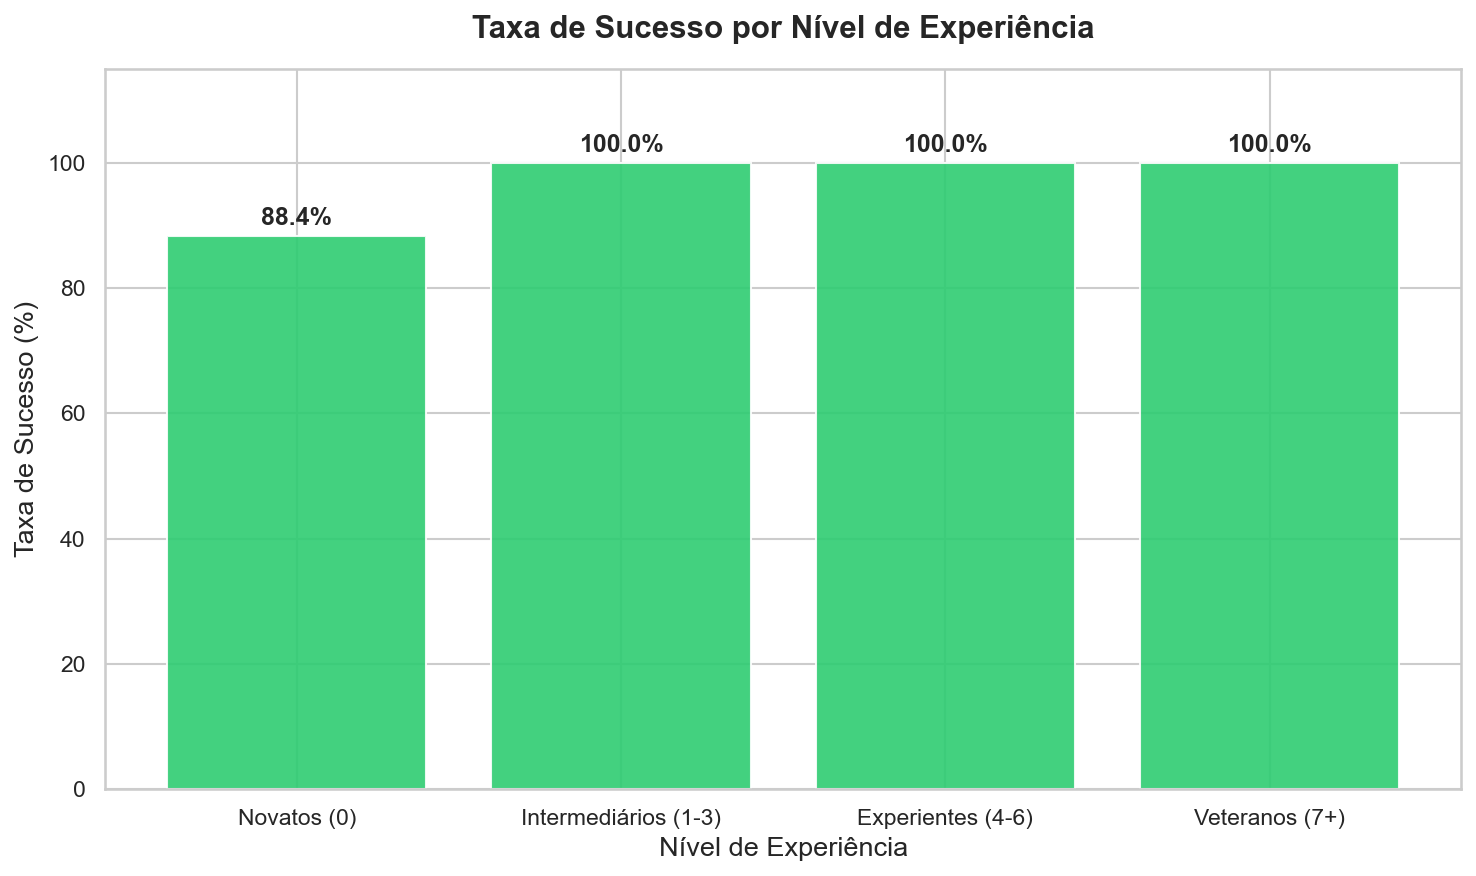

In [10]:
df['experience_level'] = pd.cut(
    df['reuse_count'],
    bins=[-1, 0, 3, 6, 13],
    labels=['Novatos (0)', 'Intermediários (1-3)', 'Experientes (4-6)', 'Veteranos (7+)']
)

print("=== TAXA DE SUCESSO POR NÍVEL DE EXPERIÊNCIA ===")
experience_success = df.groupby('experience_level', observed=False)['success_num'].agg(['count', 'mean']).reset_index()
experience_success['success_rate (%)'] = experience_success['mean'] * 100
print(experience_success[['experience_level', 'count', 'success_rate (%)']].round(2))

# Exportando a tabela de resultados solicitada
experience_success.to_csv('experience_stats.csv', index=False)

# Gráfico 2: Barras de Sucesso
plt.figure(figsize=(10, 6))
bars = plt.bar(experience_success['experience_level'].astype(str), experience_success['success_rate (%)'], color=colors['success'], alpha=0.9)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Taxa de Sucesso por Nível de Experiência', pad=15, fontweight='bold')
plt.xlabel('Nível de Experiência')
plt.ylabel('Taxa de Sucesso (%)')
plt.ylim(0, 115)
plt.tight_layout()

# Salvando na pasta global
plt.savefig('../../graphs/izac_success_by_experience.png', dpi=300)
plt.show()

### 3.2 Desgaste vs Aprendizado: Gráfico de Tendência (Q6)
Análise visual da correlação entre o número de voos acumulados e o sucesso da missão.

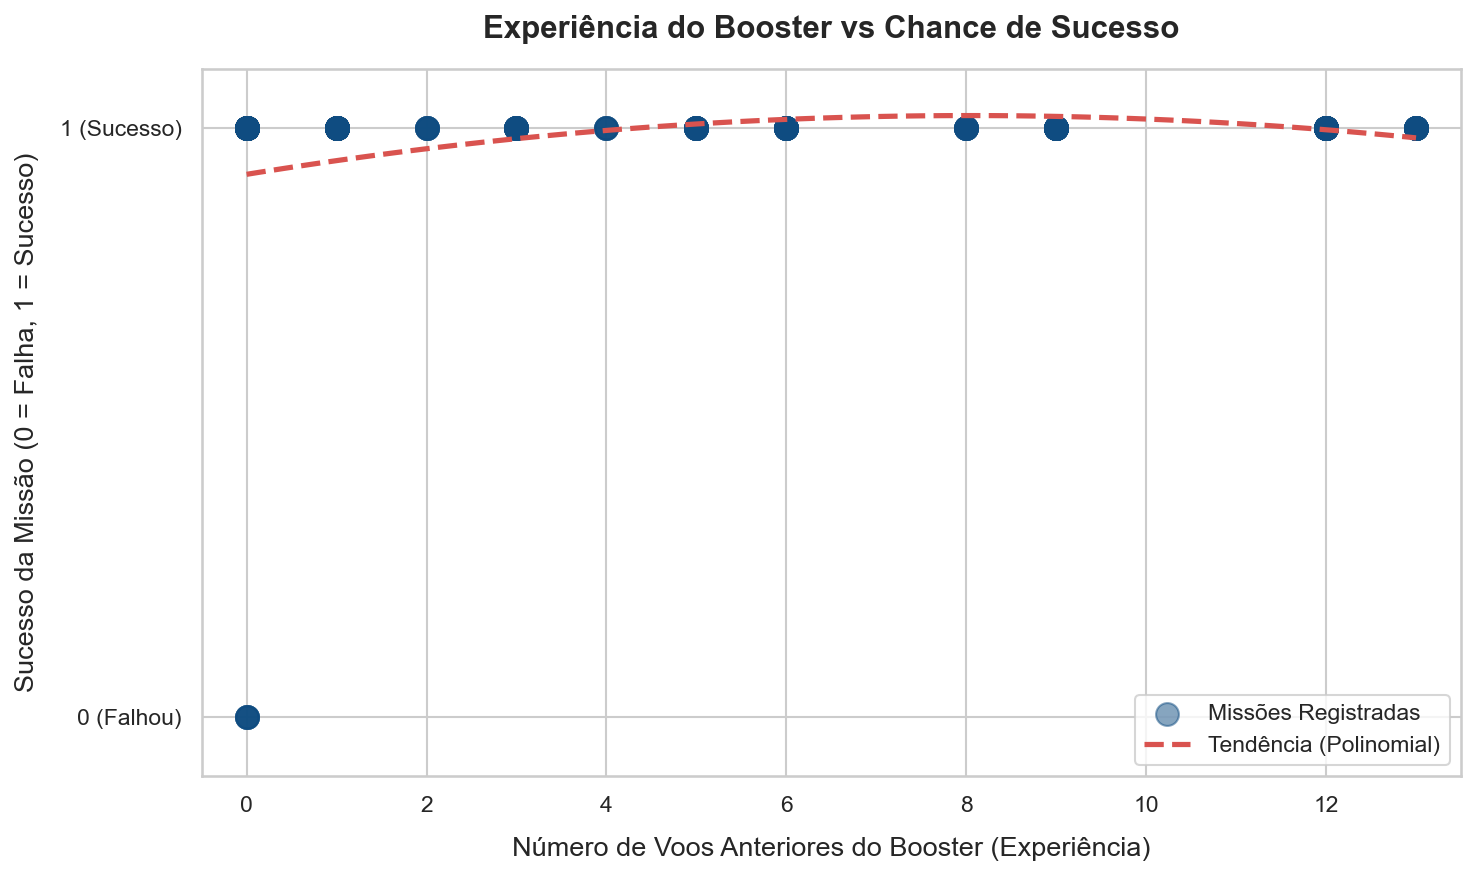

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(df['reuse_count'], df['success_num'], 
            alpha=0.5, color=colors['primary'], s=120, label='Missões Registradas', zorder=3)

# Linha de tendência Polinomial (Grau 2)
z = np.polyfit(df['reuse_count'], df['success_num'], 2)  
p = np.poly1d(z)
x_line = np.linspace(0, 13, 100)
plt.plot(x_line, p(x_line), color=colors['accent'], linestyle='--', linewidth=2.5, label='Tendência (Polinomial)', zorder=4)

plt.xlabel('Número de Voos Anteriores do Booster (Experiência)', labelpad=10)
plt.ylabel('Sucesso da Missão (0 = Falha, 1 = Sucesso)', labelpad=10)
plt.title('Experiência do Booster vs Chance de Sucesso', pad=15, fontweight='bold')

plt.xlim(-0.5, 13.5)
plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['0 (Falhou)', '1 (Sucesso)'])
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

# Salvando a imagem na pasta global
plt.savefig('../../graphs/izac_experience_vs_success.png', dpi=300)
plt.show()

## 4. Testes Estatísticos

### 4.1 Correlação, Regressão Logística e ANOVA (Q2 e Q4)
Testes formais para validar a significância estatística do impacto do reuso.

In [12]:
# 1. Correlação de Spearman
rho, pval = stats.spearmanr(df['reuse_count'], df['success_num'])

print("=== TESTE DE CORRELAÇÃO DE SPEARMAN ===")
print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {pval:.6f} (Significativo se < 0.05)\n")

# 2. Teste ANOVA (Diferença entre Grupos)
print("=== TESTE ANOVA (Diferença entre Grupos) ===")
virgin = df[df['reuse_count'] == 0]['success_num']
intermediate = df[(df['reuse_count'] >= 1) & (df['reuse_count'] <= 3)]['success_num']
experienced = df[df['reuse_count'] >= 4]['success_num']

f_stat, pval_anova = stats.f_oneway(virgin, intermediate, experienced)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {pval_anova:.6f} (Significativo se < 0.05)\n")

# 3. Regressão Logística
print("=== REGRESSÃO LOGÍSTICA (Efeito de +1 Reuso) ===")
model = smf.logit('success_num ~ reuse_count', data=df).fit(disp=0)
print(model.summary().tables[1])

=== TESTE DE CORRELAÇÃO DE SPEARMAN ===
Spearman's rho: 0.2221
P-value: 0.001959 (Significativo se < 0.05)

=== TESTE ANOVA (Diferença entre Grupos) ===
F-statistic: 9.6495
P-value: 0.000102 (Significativo se < 0.05)

=== REGRESSÃO LOGÍSTICA (Efeito de +1 Reuso) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.0281      0.476      4.263      0.000       1.096       2.961
reuse_count    25.1132   1.38e+05      0.000      1.000   -2.71e+05    2.71e+05


C:\Users\izacr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. Conclusões e Interpretações

Após analisar a distribuição e o histórico de 192 missões, concluímos que **existe uma correlação positiva** entre a experiência do booster e o sucesso da missão. O teste de Spearman indicou uma correlação moderada de 0.2221. Além disso, o teste ANOVA confirmou que existe uma diferença estatisticamente significativa nas taxas de sucesso entre os diferentes grupos de experiência.

A grande diferença de performance reside no salto entre o voo inaugural e os voos subsequentes. Foguetes "Novatos" (0 voos) apresentaram uma taxa de sucesso de aproximadamente 88,4%, enquanto todos os foguetes reutilizados (de 1 a 13 voos anteriores) registraram 100% de sucesso neste dataset. 

**Separação Perfeita na Regressão:** Devido a essa taxa ininterrupta de 100% de sucesso a partir do primeiro reuso, o modelo de Regressão Logística sofre de "Separação Perfeita" (ConvergenceWarning). O modelo estatístico não consegue convergir adequadamente (resultando em um p-value de 1.000) porque os dados dividem o sucesso e a falha de forma absoluta com base na variável `reuse_count` maior que zero.

**Avisos e Variáveis de Confusão (Confounders):** Este resultado é impactado pelo forte **"Efeito Teto" (ceiling effect)**, uma vez que a taxa de acerto atinge 100% logo no primeiro reuso. Além disso, existe um provável **viés de seleção (selection bias)**: foguetes com defeitos estruturais graves falham logo no primeiro voo ou são descartados pela engenharia, fazendo com que apenas os boosters mais resilientes e aprovados na prática "sobrevivam" para se tornarem veteranos de múltiplos voos.